# 07 — Stylistic convergence

## Configuration and reproducibility inputs

The distributed repository includes the verified standardized
representation used in the manuscript. Set `RUN_FROM_RAW_FEATURES=True`
to reconstruct it from StyloMetrix shards. Set
`RUN_FEATURE_EXTRACTION=True` only when the shards themselves must be
regenerated from abstract text; this stage requires StyloMetrix, spaCy,
its English model, and one GPU.

In [15]:
import json
import os
import time
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm
from sklearn.preprocessing import normalize
try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value.to_string(index=False) if hasattr(value, "to_string") else value)

search_roots = [Path.cwd(), *Path.cwd().parents]
REPO_ROOT = next(
    (root for root in search_roots
     if (root / "data" / "processed" / "id_papers.csv").exists()),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError("Could not locate data/processed/id_papers.csv")

PROCESSED_DIR = REPO_ROOT / "data" / "processed" / "stylistic_convergence"
SOURCE_DIR = REPO_ROOT / "data" / "source_data" / "07_stylistic_convergence"
MASTER_CSV = REPO_ROOT / "data" / "processed" / "id_papers.csv"
ABSTRACT_CSV = REPO_ROOT / "data" / "processed" / "paper_abstracts.csv"
FEATURE_SHARD_DIR = PROCESSED_DIR / "features"
REPRESENTATION_PARQUET = PROCESSED_DIR / "stylometrix_standardized_representations.parquet"
FEATURE_AUDIT_CSV = PROCESSED_DIR / "stylometrix_feature_audit.csv"
ROBUSTNESS_CACHE_DIR = PROCESSED_DIR / "robustness_cache"

LEGACY_ROOT = Path(
    "/home/user/GSK/lily/science_of_science/NewDataset/"
    "AI_impact_on_cs_publications"
)
LEGACY_ABSTRACT_CSV = LEGACY_ROOT / "Data" / "all_years_abstract_finetuned.csv"
LEGACY_FEATURE_SHARDS = (
    LEGACY_ROOT / "code_analysis" / "Results" /
    "stylistic_homogenization" / "features_parquet"
)

RUN_FEATURE_EXTRACTION = False
RUN_FROM_RAW_FEATURES = False
RUN_ROBUSTNESS_FROM_RAW = False
CUDA_DEVICE = "0"
CHUNK_SIZE = 250
EXTRACTION_BATCH_SIZE = 32
MIN_ABSTRACT_WORDS = 1
YEARS = np.arange(2020, 2026)
PRE_YEARS = np.array([2020, 2021, 2022])
POST_YEARS = np.array([2023, 2024, 2025])
REFERENCE_YEAR = 2022
MIN_CELL_SIZE = 30
BOOTSTRAP_REPS = 5_000
ROBUSTNESS_PAIRS_PER_YEAR = 200_000
ROBUSTNESS_CLUSTER_BOOTSTRAPS = 2_000
RANDOM_SEED = 20260826

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
SOURCE_DIR.mkdir(parents=True, exist_ok=True)
FEATURE_SHARD_DIR.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "sans-serif"],
    "font.size": 10.5,
    "axes.labelsize": 10.5,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "pdf.fonttype": 42,
    "svg.fonttype": "none",
})

print(f"Repository root: {REPO_ROOT}")
print(f"Processed representations: {REPRESENTATION_PARQUET}")
print(f"Source-data directory: {SOURCE_DIR}")
print({
    "run_feature_extraction": RUN_FEATURE_EXTRACTION,
    "run_from_raw_features": RUN_FROM_RAW_FEATURES,
    "run_robustness_from_raw": RUN_ROBUSTNESS_FROM_RAW,
    "bootstrap_repetitions": BOOTSTRAP_REPS,
})

Repository root: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub
Processed representations: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/processed/stylistic_convergence/stylometrix_standardized_representations.parquet
Source-data directory: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/source_data/07_stylistic_convergence
{'run_feature_extraction': False, 'run_from_raw_features': False, 'run_robustness_from_raw': False, 'bootstrap_repetitions': 5000}


## Resumable StyloMetrix extraction

In [16]:
STYLOMETRIX_CATEGORIES = [
    "PartOfSpeech", "Lexical", "Syntactic", "VerbTenses",
    "Statistics", "Pronouns", "General",
]

def normalize_text(value) -> str:
    if pd.isna(value):
        return ""
    return " ".join(str(value).replace("\n", " ").split())

def load_abstract_corpus() -> pd.DataFrame:
    path = ABSTRACT_CSV if ABSTRACT_CSV.exists() else LEGACY_ABSTRACT_CSV
    if not path.exists():
        raise FileNotFoundError(
            "Provide data/processed/paper_abstracts.csv with id, Year and abstract."
        )
    frame = pd.read_csv(path, encoding="utf-8-sig", low_memory=False)
    text_column = next(
        (c for c in ("abstract", "reconstructed_abstract", "text") if c in frame),
        None,
    )
    if text_column is None:
        raise KeyError("Abstract corpus needs abstract, reconstructed_abstract or text")
    frame = frame[["id", "Year", text_column]].copy()
    frame["id"] = frame["id"].astype("string").str.strip()
    frame["Year"] = pd.to_numeric(frame["Year"], errors="coerce")
    frame["text"] = frame[text_column].map(normalize_text)
    frame["word_count"] = frame["text"].str.split().str.len()
    frame = frame.loc[
        frame["id"].notna() & frame["id"].ne("")
        & frame["Year"].between(2020, 2025)
        & frame["word_count"].ge(MIN_ABSTRACT_WORDS),
        ["id", "Year", "text"],
    ].reset_index(drop=True)
    if frame["id"].duplicated().any():
        raise ValueError("Eligible abstract corpus contains duplicate IDs")
    frame["Year"] = frame["Year"].astype(int)
    return frame

if RUN_FEATURE_EXTRACTION:
    os.environ["CUDA_VISIBLE_DEVICES"] = CUDA_DEVICE
    import spacy
    from stylo_metrix import StyloMetrix

    corpus = load_abstract_corpus()
    total_chunks = int(np.ceil(len(corpus) / CHUNK_SIZE))
    completed = {
        int(path.stem.rsplit("_", 1)[-1])
        for path in FEATURE_SHARD_DIR.glob("stylometrix_shard_*.parquet")
        if path.stem.rsplit("_", 1)[-1].isdigit()
    }
    pending = [i for i in range(total_chunks) if i not in completed]
    print(f"Eligible papers={len(corpus):,}; pending shards={len(pending):,}")
    if not spacy.require_gpu():
        raise RuntimeError("spaCy could not activate the configured GPU")
    stylo = StyloMetrix("en", metrics=STYLOMETRIX_CATEGORIES)
    metric_objects = list(stylo._metrics)
    metric_codes = [metric.code for metric in metric_objects]
    started = time.time()
    for completed_now, chunk_index in enumerate(pending, start=1):
        start = chunk_index * CHUNK_SIZE
        stop = min(start + CHUNK_SIZE, len(corpus))
        chunk = corpus.iloc[start:stop].copy().reset_index(drop=True)
        values = []
        for doc in stylo.nlp.pipe(
            chunk["text"].tolist(), batch_size=EXTRACTION_BATCH_SIZE
        ):
            row = []
            for metric in metric_objects:
                try:
                    row.append(doc._.metrics[metric][0])
                except Exception:
                    row.append(np.nan)
            values.append(row)
        features = pd.DataFrame(values, columns=metric_codes).apply(
            pd.to_numeric, errors="coerce"
        )
        result = pd.concat([chunk[["id", "Year", "text"]], features], axis=1)
        final_path = FEATURE_SHARD_DIR / f"stylometrix_shard_{chunk_index:04d}.parquet"
        temporary_path = FEATURE_SHARD_DIR / f".{final_path.name}.tmp"
        result.to_parquet(temporary_path, index=False)
        temporary_path.replace(final_path)
        elapsed = time.time() - started
        remaining = elapsed / completed_now * (len(pending) - completed_now)
        print(
            f"[{completed_now}/{len(pending)}] shard={chunk_index:04d}; "
            f"rows={len(result)}; ETA={remaining / 60:.1f} min",
            flush=True,
        )
else:
    shard_dir = FEATURE_SHARD_DIR
    if not list(shard_dir.glob("stylometrix_shard_*.parquet")):
        shard_dir = LEGACY_FEATURE_SHARDS
    print("[SKIP] StyloMetrix extraction is disabled.")
    print(f"Available shard directory: {shard_dir}")
    print(f"Available shards: {len(list(shard_dir.glob('stylometrix_shard_*.parquet'))):,}")

[SKIP] StyloMetrix extraction is disabled.
Available shard directory: /home/user/GSK/lily/science_of_science/NewDataset/AI_impact_on_cs_publications/code_analysis/Results/stylistic_homogenization/features_parquet
Available shards: 368


## Feature audit and pre-period standardization

In [17]:
NON_STYLE_CODES = {
    "L_REF", "L_HASHTAG", "L_MENTION", "L_RT", "L_LINKS",
    "L_CONT_A", "L_CONT_T", "L_PLURAL_NOUNS", "L_SINGULAR_NOUNS",
    "L_PROPER_NAME", "L_PERSONAL_NAME", "L_NOUN_PHRASES",
}
METADATA_COLUMNS = {"corpus_position", "id", "Year", "Conference", "track_type", "text"}

if RUN_FROM_RAW_FEATURES:
    shard_dir = FEATURE_SHARD_DIR
    if not list(shard_dir.glob("stylometrix_shard_*.parquet")):
        shard_dir = LEGACY_FEATURE_SHARDS
    shard_paths = sorted(shard_dir.glob("stylometrix_shard_*.parquet"))
    if not shard_paths:
        raise FileNotFoundError("No StyloMetrix feature shards found")
    raw = pd.concat([pd.read_parquet(path) for path in shard_paths], ignore_index=True)
    raw["id"] = raw["id"].astype("string").str.strip()
    if raw["id"].duplicated().any():
        raise ValueError("Duplicate paper IDs across feature shards")

    master = pd.read_csv(
        MASTER_CSV,
        usecols=["id", "Conference", "Year", "track_type"],
        encoding="utf-8-sig",
        low_memory=False,
    )
    master["id"] = master["id"].astype("string").str.strip()
    master["Year"] = pd.to_numeric(master["Year"], errors="raise").astype(int)
    raw = raw.merge(
        master, on="id", how="inner", suffixes=("_shard", "_master"),
        validate="one_to_one",
    )
    if "Year_shard" in raw:
        mismatch = raw["Year_shard"].astype(int).ne(raw["Year_master"])
        if mismatch.any():
            raise ValueError(f"Year mismatch for {int(mismatch.sum()):,} papers")
        raw["Year"] = raw.pop("Year_master").astype(int)
        raw.drop(columns="Year_shard", inplace=True)
    raw = raw.loc[raw["Year"].between(2020, 2025)].sort_values("id").reset_index(drop=True)

    candidate_features = [
        c for c in raw.columns if c not in METADATA_COLUMNS and c not in NON_STYLE_CODES
    ]
    pre_mask = raw["Year"].between(2020, 2022)
    pre = raw.loc[pre_mask, candidate_features].apply(pd.to_numeric, errors="coerce")
    missing_rate = pre.isna().mean()
    variance = pre.var(skipna=True)
    selected_features = [
        c for c in candidate_features
        if missing_rate[c] <= 0.05 and variance[c] > 1e-10
    ]
    values = raw[selected_features].apply(pd.to_numeric, errors="coerce")
    values = values.fillna(pre[selected_features].median())
    lower = values.loc[pre_mask].quantile(0.01)
    upper = values.loc[pre_mask].quantile(0.99)
    values = values.clip(lower=lower, upper=upper, axis=1)
    pre_values = values.loc[pre_mask]
    z = (
        (values - pre_values.mean())
        / pre_values.std(ddof=0).replace(0, np.nan)
    ).fillna(0.0)
    representation = pd.concat(
        [
            raw[["id", "Year", "Conference", "track_type"]].reset_index(drop=True),
            z.reset_index(drop=True).add_prefix("z_"),
        ],
        axis=1,
    )
    audit = pd.DataFrame({
        "feature": candidate_features,
        "pre_missing_rate": [missing_rate[c] for c in candidate_features],
        "pre_variance": [variance[c] for c in candidate_features],
        "excluded_non_style": False,
        "selected": [c in selected_features for c in candidate_features],
    })
    audit = pd.concat([
        audit,
        pd.DataFrame({
            "feature": sorted(NON_STYLE_CODES),
            "pre_missing_rate": np.nan,
            "pre_variance": np.nan,
            "excluded_non_style": True,
            "selected": False,
        }),
    ], ignore_index=True)
    representation.to_parquet(REPRESENTATION_PARQUET, index=False)
    audit.to_csv(FEATURE_AUDIT_CSV, index=False, encoding="utf-8-sig")
    print("Reconstructed and saved standardized representations.")
else:
    if not REPRESENTATION_PARQUET.exists():
        raise FileNotFoundError(
            f"Missing {REPRESENTATION_PARQUET}; set RUN_FROM_RAW_FEATURES=True."
        )
    representation = pd.read_parquet(REPRESENTATION_PARQUET)
    audit = pd.read_csv(FEATURE_AUDIT_CSV, encoding="utf-8-sig")
    print("Reusing verified standardized representations.")

feature_columns = [c for c in representation if c.startswith("z_")]
if len(representation) != 91_856:
    raise ValueError(f"Expected 91,856 papers, found {len(representation):,}")
if len(feature_columns) != 155:
    raise ValueError(f"Expected 155 retained features, found {len(feature_columns)}")
if representation["id"].duplicated().any():
    raise ValueError("Standardized representation contains duplicate IDs")
print(f"Papers: {len(representation):,}")
print(f"Retained features for multivariate analysis: {len(feature_columns)}")
display(representation.groupby("Year").size().rename("n_papers").reset_index())
display(audit.groupby(["excluded_non_style", "selected"]).size().rename("n_features").reset_index())

Reusing verified standardized representations.
Papers: 91,856
Retained features for multivariate analysis: 155


,Year,n_papers
0,2020,10030
1,2021,10983
2,2022,11749
3,2023,15724
4,2024,18789
5,2025,24581


,excluded_non_style,selected,n_features
0,False,False,12
1,False,True,155
2,True,False,12


## Annual multivariate distance and similarity

In [18]:
def annual_statistics(matrix: np.ndarray):
    n = len(matrix)
    centered = matrix - matrix.mean(axis=0, keepdims=True)
    squared_deviation = np.square(centered, dtype=np.float64).sum(axis=1)
    distance = float(np.sqrt(2.0 * squared_deviation.sum() / (n - 1)))
    unit = normalize(matrix, norm="l2", axis=1)
    vector_sum = np.asarray(unit.sum(axis=0)).ravel()
    similarity = float((vector_sum @ vector_sum - n) / (n * (n - 1)))
    h_i = (np.asarray(unit @ vector_sum).ravel() - 1.0) / (n - 1)
    return distance, squared_deviation, similarity, h_i

def bootstrap_means(values, reps, rng, batch_size=64):
    output = np.empty(reps, dtype=float)
    n = len(values)
    for start in range(0, reps, batch_size):
        stop = min(start + batch_size, reps)
        indices = rng.integers(0, n, size=(stop - start, n))
        output[start:stop] = values[indices].mean(axis=1)
    return output

def fit_line(years, values, grid):
    slope, intercept = np.polyfit(years - 2022, values, 1)
    return float(slope), slope * (grid - 2022) + intercept

def slope_and_fit_source(metric, estimates, bootstrap):
    rows = []
    fit_rows = []
    for period, year_index, period_years in [
        ("2020–2022", np.array([0, 1, 2]), PRE_YEARS),
        ("2023–2025", np.array([3, 4, 5]), POST_YEARS),
    ]:
        grid = np.linspace(period_years.min(), period_years.max(), 100)
        slope, fitted = fit_line(period_years, estimates[year_index], grid)
        boot_slopes = np.empty(len(bootstrap))
        predictions = np.empty((len(bootstrap), len(grid)))
        for b, draw in enumerate(bootstrap):
            boot_slopes[b], predictions[b] = fit_line(
                period_years, draw[year_index], grid
            )
        rows.append({
            "metric": metric,
            "quantity": "pre_slope" if period == "2020–2022" else "post_slope",
            "estimate": slope,
            "ci_low": np.quantile(boot_slopes, 0.025),
            "ci_high": np.quantile(boot_slopes, 0.975),
        })
        low, high = np.quantile(predictions, [0.025, 0.975], axis=0)
        fit_rows.extend({
            "metric": metric, "period": period, "grid_year": x,
            "fitted": y, "ci_low": lo, "ci_high": hi,
        } for x, y, lo, hi in zip(grid, fitted, low, high))
        if period == "2020–2022":
            pre_slope, pre_boot = slope, boot_slopes
        else:
            post_slope, post_boot = slope, boot_slopes
    change = post_boot - pre_boot
    rows.append({
        "metric": metric,
        "quantity": "post_minus_pre_slope_change",
        "estimate": post_slope - pre_slope,
        "ci_low": np.quantile(change, 0.025),
        "ci_high": np.quantile(change, 0.975),
    })
    return pd.DataFrame(rows), pd.DataFrame(fit_rows)

matrix_all = representation[feature_columns].to_numpy(dtype=np.float64)
annual_rows = []
distance_components = {}
similarity_influences = {}
for year in YEARS:
    current = matrix_all[representation["Year"].to_numpy() == year]
    distance, q_i, similarity, h_i = annual_statistics(current)
    annual_rows.append({
        "Year": int(year), "n_papers": len(current),
        "rms_pairwise_stylometric_distance": distance,
        "mean_pairwise_cosine_similarity": similarity,
    })
    distance_components[int(year)] = q_i
    similarity_influences[int(year)] = h_i
annual = pd.DataFrame(annual_rows)

rng = np.random.default_rng(RANDOM_SEED)
distance_boot = np.empty((BOOTSTRAP_REPS, len(YEARS)))
similarity_boot = np.empty_like(distance_boot)
for column, year in enumerate(YEARS):
    n = int(annual.loc[annual["Year"].eq(year), "n_papers"].iloc[0])
    q_mean = bootstrap_means(distance_components[int(year)], BOOTSTRAP_REPS, rng)
    distance_boot[:, column] = np.sqrt(2.0 * n / (n - 1) * q_mean)
    h_i = similarity_influences[int(year)]
    h_mean = bootstrap_means(h_i, BOOTSTRAP_REPS, rng)
    theta = annual.loc[
        annual["Year"].eq(year), "mean_pairwise_cosine_similarity"
    ].iloc[0]
    similarity_boot[:, column] = theta + 2.0 * (h_mean - theta)

annual["distance_ci_low"], annual["distance_ci_high"] = np.quantile(
    distance_boot, [0.025, 0.975], axis=0
)
annual["similarity_ci_low"], annual["similarity_ci_high"] = np.quantile(
    similarity_boot, [0.025, 0.975], axis=0
)
distance_stats, distance_fit = slope_and_fit_source(
    "rms_pairwise_stylometric_distance",
    annual["rms_pairwise_stylometric_distance"].to_numpy(),
    distance_boot,
)
similarity_stats, similarity_fit = slope_and_fit_source(
    "mean_pairwise_cosine_similarity",
    annual["mean_pairwise_cosine_similarity"].to_numpy(),
    similarity_boot,
)
slope_stats = pd.concat([distance_stats, similarity_stats], ignore_index=True)
trend_fits = pd.concat([distance_fit, similarity_fit], ignore_index=True)

annual.to_csv(SOURCE_DIR / "annual_distance_similarity.csv", index=False)
slope_stats.to_csv(SOURCE_DIR / "distance_similarity_slope_statistics.csv", index=False)
trend_fits.to_csv(SOURCE_DIR / "distance_similarity_trend_fits.csv", index=False)
display(annual)
display(slope_stats)

,Year,n_papers,rms_pairwise_stylometric_distance,mean_pairwise_cosine_similarity,distance_ci_low,distance_ci_high,similarity_ci_low,similarity_ci_high
0,2020,10030,13.856988,0.001747,13.785224,13.930522,0.001406,0.002072
1,2021,10983,13.635337,0.000942,13.570480,13.703869,0.000738,0.001144
2,2022,11749,13.647192,0.001964,13.578491,13.717162,0.001653,0.002272
3,2023,15724,13.461713,0.004138,13.406247,13.518902,0.003737,0.004556
4,2024,18789,13.068381,0.023564,13.016387,13.120634,0.022563,0.024585
5,2025,24581,12.758888,0.070549,12.712787,12.803759,0.068951,0.072138


,metric,quantity,estimate,ci_low,ci_high
0,rms_pairwise_stylometric_distance,pre_slope,-0.104898,-0.154837,-0.056082
1,rms_pairwise_stylometric_distance,post_slope,-0.351413,-0.388466,-0.316374
2,rms_pairwise_stylometric_distance,post_minus_pre_slope_change,-0.246515,-0.307402,-0.185306
3,mean_pairwise_cosine_similarity,pre_slope,0.000108,-0.000116,0.000336
4,mean_pairwise_cosine_similarity,post_slope,0.033206,0.032359,0.034033
5,mean_pairwise_cosine_similarity,post_minus_pre_slope_change,0.033097,0.032238,0.033969


## RMS pairwise stylometric distance

In [ ]:
annual_plot = pd.read_csv(SOURCE_DIR / "annual_distance_similarity.csv")
fit_plot = pd.read_csv(SOURCE_DIR / "distance_similarity_trend_fits.csv")
metric = "rms_pairwise_stylometric_distance"
fig, ax = plt.subplots(figsize=(5.8, 4.1))
for period, color in [("2020–2022", "#6B7280"), ("2023–2025", "#2878B5")]:
    part = fit_plot.loc[(fit_plot["metric"] == metric) & (fit_plot["period"] == period)]
    ax.fill_between(part["grid_year"], part["ci_low"], part["ci_high"], color=color, alpha=0.17)
    ax.plot(part["grid_year"], part["fitted"], color=color, lw=1.8, label=f"{period} trend")
values = annual_plot[metric].to_numpy()
ax.errorbar(
    annual_plot["Year"], values,
    yerr=np.vstack([values - annual_plot["distance_ci_low"], annual_plot["distance_ci_high"] - values]),
    fmt="o", color="#1F2937", markerfacecolor="white", capsize=3, zorder=5,
)
ax.axvline(2022.5, color="#9CA3AF", linestyle=(0, (4, 3)), lw=1)
ax.set(xlabel="Publication year", ylabel="RMS pairwise stylometric distance", xticks=YEARS)
ax.grid(axis="y", alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

## Mean pairwise cosine similarity

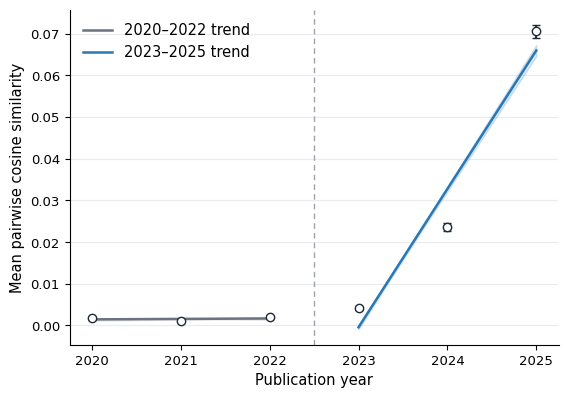

In [19]:
metric = "mean_pairwise_cosine_similarity"
fig, ax = plt.subplots(figsize=(5.8, 4.1))
for period, color in [("2020–2022", "#6B7280"), ("2023–2025", "#2878B5")]:
    part = fit_plot.loc[(fit_plot["metric"] == metric) & (fit_plot["period"] == period)]
    ax.fill_between(part["grid_year"], part["ci_low"], part["ci_high"], color=color, alpha=0.17)
    ax.plot(part["grid_year"], part["fitted"], color=color, lw=1.8, label=f"{period} trend")
values = annual_plot[metric].to_numpy()
ax.errorbar(
    annual_plot["Year"], values,
    yerr=np.vstack([values - annual_plot["similarity_ci_low"], annual_plot["similarity_ci_high"] - values]),
    fmt="o", color="#1F2937", markerfacecolor="white", capsize=3, zorder=5,
)
ax.axvline(2022.5, color="#9CA3AF", linestyle=(0, (4, 3)), lw=1)
ax.set(xlabel="Publication year", ylabel="Mean pairwise cosine similarity", xticks=YEARS)
ax.grid(axis="y", alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

## Conference–track composition standardization

In [20]:
def pairwise_metrics(matrix):
    n = len(matrix)
    unit = normalize(matrix, norm="l2", axis=1)
    vector_sum = np.asarray(unit.sum(axis=0)).ravel()
    cosine = float((vector_sum @ vector_sum - n) / (n * (n - 1)))
    centered = matrix - matrix.mean(axis=0, keepdims=True)
    distance = float(np.sqrt(2.0 * np.square(centered).sum() / (n - 1)))
    return cosine, distance

cell_rows = []
for key, indices in representation.groupby(
    ["Conference", "Year", "track_type"], observed=True, sort=True
).indices.items():
    idx = np.asarray(indices)
    if len(idx) < MIN_CELL_SIZE:
        continue
    cosine, distance = pairwise_metrics(matrix_all[idx])
    cell_rows.append({
        "Conference": key[0], "Year": int(key[1]), "track_type": key[2],
        "n_papers": len(idx), "mean_pairwise_cosine_similarity": cosine,
        "rms_pairwise_euclidean_distance": distance,
    })
cells = pd.DataFrame(cell_rows)
presence = cells.assign(present=1).pivot_table(
    index=["Conference", "track_type"], columns="Year",
    values="present", fill_value=0,
)
common_index = presence.index[presence.reindex(columns=YEARS, fill_value=0).eq(1).all(axis=1)]
common = cells.set_index(["Conference", "track_type"]).loc[common_index].reset_index()
weights = common.loc[common["Year"].eq(REFERENCE_YEAR), ["Conference", "track_type", "n_papers"]].copy()
weights["weight"] = weights["n_papers"] / weights["n_papers"].sum()
common = common.merge(weights[["Conference", "track_type", "weight"]], on=["Conference", "track_type"])
standardized_rows = []
for year, group in common.groupby("Year", observed=True):
    w = group["weight"] / group["weight"].sum()
    standardized_rows.append({
        "Year": int(year), "common_cells": len(group),
        "mean_pairwise_cosine_similarity": np.average(group["mean_pairwise_cosine_similarity"], weights=w),
        "rms_pairwise_euclidean_distance": np.average(group["rms_pairwise_euclidean_distance"], weights=w),
    })
standardized = pd.DataFrame(standardized_rows).sort_values("Year")
cells.to_csv(SOURCE_DIR / "conference_year_track_metrics.csv", index=False)
weights.to_csv(SOURCE_DIR / "conference_track_2022_weights.csv", index=False)
standardized.to_csv(SOURCE_DIR / "annual_composition_standardized_metrics.csv", index=False)
display(standardized)

,Year,common_cells,mean_pairwise_cosine_similarity,rms_pairwise_euclidean_distance
0,2020,18,0.015600,13.754264
1,2021,18,0.014507,13.547909
2,2022,18,0.015334,13.529107
3,2023,18,0.018429,13.299810
4,2024,18,0.039635,12.982873
5,2025,18,0.090345,12.618435


## Robustness of the convergence slope change

In [21]:
ROBUSTNESS_FILES = [
    "robustness_annual_metrics.csv",
    "robustness_slope_summary.csv",
    "feature_length_correlations.csv",
    "robust_sampled_pair_metrics.csv",
    "robust_sampled_pair_slope_summary.csv",
    "first_author_cluster_bootstrap_replicates.csv",
    "first_author_cluster_bootstrap_slope_summary.csv",
    "first_author_cluster_bootstrap_annual_summary.csv",
]

def robustness_annual_metrics(matrix, years):
    rows = []
    for year in YEARS:
        current = matrix[years == year]
        cosine, distance = pairwise_metrics(current)
        rows.append({
            "Year": int(year), "n_papers": len(current),
            "mean_pairwise_cosine_similarity": cosine,
            "rms_pairwise_euclidean_distance": distance,
        })
    return pd.DataFrame(rows)

def robustness_slope_summary(annual_frame):
    indexed = annual_frame.set_index("Year")
    d_pre = (indexed.loc[2022, "rms_pairwise_euclidean_distance"] - indexed.loc[2020, "rms_pairwise_euclidean_distance"]) / 2
    d_post = (indexed.loc[2025, "rms_pairwise_euclidean_distance"] - indexed.loc[2023, "rms_pairwise_euclidean_distance"]) / 2
    c_pre = (indexed.loc[2022, "mean_pairwise_cosine_similarity"] - indexed.loc[2020, "mean_pairwise_cosine_similarity"]) / 2
    c_post = (indexed.loc[2025, "mean_pairwise_cosine_similarity"] - indexed.loc[2023, "mean_pairwise_cosine_similarity"]) / 2
    return {
        "distance_pre_slope": d_pre, "distance_post_slope": d_post,
        "distance_slope_change": d_post - d_pre,
        "cosine_pre_slope": c_pre, "cosine_post_slope": c_post,
        "cosine_slope_change": c_post - c_pre,
        "supports_convergence": bool(d_post - d_pre < 0 and c_post - c_pre > 0),
    }

def z_standardize(values, fit_mask):
    fit = values.loc[fit_mask]
    result = (values - fit.mean()) / fit.std(ddof=0).replace(0, np.nan)
    return result.fillna(0.0).to_numpy(dtype=np.float32), list(result.columns)

def robust_iqr_standardize(values, fit_mask):
    fit = values.loc[fit_mask]
    median = fit.median()
    iqr = fit.quantile(0.75) - fit.quantile(0.25)
    keep = iqr.gt(1e-10) & iqr.notna()
    result = (values.loc[:, keep] - median[keep]) / iqr[keep]
    return result.fillna(0.0).to_numpy(dtype=np.float32), list(result.columns)

def residualize_length(matrix, log_length, pre_mask):
    centered = log_length - log_length[pre_mask].mean()
    design = np.column_stack([np.ones(len(centered)), centered, centered ** 2])
    coefficients, _, _, _ = np.linalg.lstsq(
        design[pre_mask], np.asarray(matrix[pre_mask], dtype=np.float64), rcond=None
    )
    residual = np.asarray(matrix, dtype=np.float64) - design @ coefficients
    pre = residual[pre_mask]
    sd = pre.std(axis=0)
    valid = np.isfinite(sd) & (sd > 1e-10)
    output = np.zeros_like(residual)
    output[:, valid] = (residual[:, valid] - pre.mean(axis=0)[valid]) / sd[valid]
    return output.astype(np.float32)

def trimmed_mean(values, proportion=0.10):
    ordered = np.sort(values)
    trim = int(np.floor(len(ordered) * proportion))
    return float(ordered[trim:-trim].mean()) if trim else float(ordered.mean())

def sampled_pair_metrics(matrix, years, pairs_per_year, seed):
    rows = []
    for year in YEARS:
        current = np.asarray(matrix[years == year], dtype=np.float32)
        n = len(current)
        norms = np.linalg.norm(current, axis=1)
        rng = np.random.default_rng(seed + int(year))
        first = rng.integers(0, n, size=pairs_per_year)
        second = rng.integers(0, n, size=pairs_per_year)
        equal = first == second
        while equal.any():
            second[equal] = rng.integers(0, n, size=int(equal.sum()))
            equal = first == second
        left, right = current[first], current[second]
        distance = np.sqrt(np.square(left - right).sum(axis=1, dtype=np.float64))
        denominator = norms[first] * norms[second]
        numerator = np.einsum("ij,ij->i", left, right, dtype=np.float64)
        cosine = np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator > 0)
        rows.append({
            "Year": int(year), "n_papers": n, "sampled_pairs": pairs_per_year,
            "mean_euclidean_distance": distance.mean(),
            "median_euclidean_distance": np.median(distance),
            "trimmed_mean_euclidean_distance": trimmed_mean(distance),
            "mean_cosine_similarity": cosine.mean(),
            "median_cosine_similarity": np.median(cosine),
            "trimmed_mean_cosine_similarity": trimmed_mean(cosine),
        })
    return pd.DataFrame(rows)

def sampled_pair_slopes(pair_frame):
    rows = []
    indexed = pair_frame.set_index("Year")
    for metric in [
        "mean_euclidean_distance", "median_euclidean_distance",
        "trimmed_mean_euclidean_distance", "mean_cosine_similarity",
        "median_cosine_similarity", "trimmed_mean_cosine_similarity",
    ]:
        pre = (indexed.loc[2022, metric] - indexed.loc[2020, metric]) / 2
        post = (indexed.loc[2025, metric] - indexed.loc[2023, metric]) / 2
        rows.append({"metric": metric, "pre_slope": pre, "post_slope": post, "slope_change": post - pre})
    return pd.DataFrame(rows)

def prepare_author_year_sufficient_statistics(matrix, years, cluster_codes):
    # Aggregate vectors by first-author cluster within each year.
    prepared = {}
    norms = np.linalg.norm(matrix, axis=1)
    unit = np.divide(
        matrix, norms[:, None], out=np.zeros_like(matrix, dtype=np.float32),
        where=norms[:, None] > 0,
    )
    row_norm_sq = np.square(matrix).sum(axis=1, dtype=np.float64)
    nonzero = (norms > 0).astype(np.float64)
    for year in YEARS:
        mask = years == year
        codes = cluster_codes[mask]
        unique, inverse = np.unique(codes, return_inverse=True)
        group_count = np.bincount(inverse).astype(np.float64)
        group_nonzero = np.bincount(inverse, weights=nonzero[mask]).astype(np.float64)
        group_norm_sq = np.bincount(inverse, weights=row_norm_sq[mask]).astype(np.float64)
        group_sum = np.zeros((len(unique), matrix.shape[1]), dtype=np.float32)
        group_unit_sum = np.zeros_like(group_sum)
        np.add.at(group_sum, inverse, matrix[mask])
        np.add.at(group_unit_sum, inverse, unit[mask])
        prepared[int(year)] = {
            "global_codes": unique, "count": group_count,
            "nonzero": group_nonzero, "norm_sq": group_norm_sq,
            "sum": group_sum, "unit_sum": group_unit_sum,
        }
    return prepared

def author_cluster_bootstrap(matrix, years, authors, paper_ids, repetitions, seed, batch_size=25):
    # Resample first-author clusters and recompute annual metrics/slopes.
    cluster = authors.astype("string").str.strip()
    missing = cluster.isna() | cluster.eq("")
    cluster = cluster.astype(object)
    cluster.loc[missing] = "paper:" + paper_ids.loc[missing].astype(str)
    cluster_codes, unique_clusters = pd.factorize(cluster, sort=False)
    n_clusters = len(unique_clusters)
    prepared = prepare_author_year_sufficient_statistics(matrix, years, cluster_codes)

    rng = np.random.default_rng(seed)
    annual_distance = np.full((repetitions, len(YEARS)), np.nan)
    annual_cosine = np.full_like(annual_distance, np.nan)
    probabilities = np.full(n_clusters, 1.0 / n_clusters)
    for start in range(0, repetitions, batch_size):
        stop = min(start + batch_size, repetitions)
        weights = rng.multinomial(
            n_clusters, probabilities, size=stop - start
        ).astype(np.float64)
        for year_index, year in enumerate(YEARS):
            stats = prepared[int(year)]
            local_weights = weights[:, stats["global_codes"]]
            n = local_weights @ stats["count"]
            nonzero_n = local_weights @ stats["nonzero"]
            total_norm_sq = local_weights @ stats["norm_sq"]
            vector_sum = local_weights @ stats["sum"]
            unit_sum = local_weights @ stats["unit_sum"]
            sse = total_norm_sq - np.square(vector_sum).sum(axis=1) / n
            annual_distance[start:stop, year_index] = np.sqrt(
                np.maximum(2.0 * sse / (n - 1.0), 0.0)
            )
            annual_cosine[start:stop, year_index] = (
                np.square(unit_sum).sum(axis=1) - nonzero_n
            ) / (n * (n - 1.0))

    replicate_rows = []
    for repetition in range(repetitions):
        d_pre = (annual_distance[repetition, 2] - annual_distance[repetition, 0]) / 2
        d_post = (annual_distance[repetition, 5] - annual_distance[repetition, 3]) / 2
        c_pre = (annual_cosine[repetition, 2] - annual_cosine[repetition, 0]) / 2
        c_post = (annual_cosine[repetition, 5] - annual_cosine[repetition, 3]) / 2
        replicate_rows.append({
            "replicate": repetition + 1,
            "distance_pre_slope": d_pre, "distance_post_slope": d_post,
            "distance_slope_change": d_post - d_pre,
            "cosine_pre_slope": c_pre, "cosine_post_slope": c_post,
            "cosine_slope_change": c_post - c_pre,
        })
    replicates = pd.DataFrame(replicate_rows)
    point_annual = robustness_annual_metrics(matrix, years)
    point_slopes = robustness_slope_summary(point_annual)
    summary_rows = []
    for metric in [
        "distance_pre_slope", "distance_post_slope", "distance_slope_change",
        "cosine_pre_slope", "cosine_post_slope", "cosine_slope_change",
    ]:
        values = replicates[metric].to_numpy()
        summary_rows.append({
            "estimand": metric, "estimate": point_slopes[metric],
            "bootstrap_mean": values.mean(),
            "ci_low": np.quantile(values, 0.025),
            "ci_high": np.quantile(values, 0.975),
            "bootstrap_repetitions": repetitions,
            "n_first_author_clusters": n_clusters,
        })
    annual_rows = []
    point_indexed = point_annual.set_index("Year")
    for year_index, year in enumerate(YEARS):
        for metric, samples in [
            ("rms_pairwise_euclidean_distance", annual_distance[:, year_index]),
            ("mean_pairwise_cosine_similarity", annual_cosine[:, year_index]),
        ]:
            annual_rows.append({
                "Year": int(year), "metric": metric,
                "estimate": point_indexed.loc[int(year), metric],
                "ci_low": np.quantile(samples, 0.025),
                "ci_high": np.quantile(samples, 0.975),
            })
    return replicates, pd.DataFrame(summary_rows), pd.DataFrame(annual_rows)

if RUN_ROBUSTNESS_FROM_RAW:
    selected_codes = audit.loc[audit["selected"].astype(bool), "feature"].tolist()
    shard_dir = FEATURE_SHARD_DIR
    if not list(shard_dir.glob("stylometrix_shard_*.parquet")):
        shard_dir = LEGACY_FEATURE_SHARDS
    raw = pd.concat([
        pd.read_parquet(path, columns=["id", "Year", "text", *selected_codes])
        for path in sorted(shard_dir.glob("stylometrix_shard_*.parquet"))
    ], ignore_index=True)
    raw["id"] = raw["id"].astype("string").str.strip()
    raw["Year"] = pd.to_numeric(raw["Year"], errors="raise").astype(int)
    raw = raw.loc[raw["Year"].between(2020, 2025)].sort_values("id").reset_index(drop=True)
    author_lookup = pd.read_csv(
        MASTER_CSV, usecols=["id", "first_author_id"],
        encoding="utf-8-sig", low_memory=False,
    )
    author_lookup["id"] = author_lookup["id"].astype("string").str.strip()
    raw = raw.merge(author_lookup, on="id", how="left", validate="one_to_one")
    years = raw["Year"].to_numpy()
    pre_mask = np.isin(years, PRE_YEARS)
    word_count = raw["text"].fillna("").astype(str).str.split().str.len().to_numpy()
    log_length = np.log1p(word_count.astype(float))
    raw_values = raw[selected_codes].apply(pd.to_numeric, errors="coerce")
    filled = raw_values.fillna(raw_values.loc[pre_mask].median())
    lower = filled.loc[pre_mask].quantile(0.01)
    upper = filled.loc[pre_mask].quantile(0.99)
    primary_values = filled.clip(lower=lower, upper=upper, axis=1)
    primary_matrix, primary_features = z_standardize(primary_values, pre_mask)

    annual_outputs, slope_outputs = [], []
    def record_specification(name, family, description, matrix, features):
        current = robustness_annual_metrics(matrix, years)
        current.insert(0, "specification", name)
        current.insert(1, "family", family)
        current.insert(2, "n_features", len(features))
        annual_outputs.append(current)
        slope_outputs.append({
            "specification": name, "family": family,
            "description": description, "n_features": len(features),
            **robustness_slope_summary(current),
        })

    record_specification("primary_pre_z_winsor_1_99", "Primary", "Pre-period z-scaling after pre-period 1st/99th percentile winsorization", primary_matrix, primary_features)
    matrix, features = z_standardize(filled, pre_mask)
    record_specification("no_winsorization", "Outliers", "No winsorization; pre-period z-scaling", matrix, features)
    tighter = filled.clip(lower=filled.loc[pre_mask].quantile(0.025), upper=filled.loc[pre_mask].quantile(0.975), axis=1)
    matrix, features = z_standardize(tighter, pre_mask)
    record_specification("winsor_2_5_97_5", "Outliers", "Pre-period 2.5th/97.5th percentile winsorization and pre-period z-scaling", matrix, features)
    matrix, features = z_standardize(primary_values, np.ones(len(raw), dtype=bool))
    record_specification("full_corpus_z_scaling", "Scaling", "Full-corpus z-scaling after pre-period winsorization", matrix, features)
    matrix, features = robust_iqr_standardize(primary_values, pre_mask)
    record_specification("pre_median_iqr_scaling", "Scaling", "Pre-period median/IQR scaling after pre-period winsorization", matrix, features)
    matrix = residualize_length(primary_matrix, log_length, pre_mask)
    record_specification("length_residualized", "Abstract length", "Quadratic log-word-count association fitted in 2020–2022 and removed from all years", matrix, primary_features)

    from scipy.stats import rankdata
    length_rank = rankdata(log_length[pre_mask])
    length_rank = (length_rank - length_rank.mean()) / length_rank.std(ddof=0)
    correlation_rows = []
    for index, feature in enumerate(primary_features):
        feature_rank = rankdata(primary_matrix[pre_mask, index])
        rho = np.nan if feature_rank.std(ddof=0) == 0 else np.mean(length_rank * ((feature_rank - feature_rank.mean()) / feature_rank.std(ddof=0)))
        correlation_rows.append({"feature": feature, "category": feature_category(feature), "spearman_rho_log_word_count_pre": rho, "abs_spearman_rho": abs(rho) if np.isfinite(rho) else np.nan})
    correlations = pd.DataFrame(correlation_rows).sort_values("abs_spearman_rho", ascending=False)
    keep = np.array([correlations.set_index("feature").loc[f, "abs_spearman_rho"] <= 0.30 for f in primary_features])
    record_specification("length_insensitive_features", "Abstract length", "Features with pre-period |Spearman rho with log word count| <= 0.30", primary_matrix[:, keep], list(np.asarray(primary_features)[keep]))

    pd.concat(annual_outputs).to_csv(SOURCE_DIR / "robustness_annual_metrics.csv", index=False)
    pd.DataFrame(slope_outputs).to_csv(SOURCE_DIR / "robustness_slope_summary.csv", index=False)
    correlations.to_csv(SOURCE_DIR / "feature_length_correlations.csv", index=False)
    pair_results = sampled_pair_metrics(primary_matrix, years, ROBUSTNESS_PAIRS_PER_YEAR, RANDOM_SEED)
    pair_results.to_csv(SOURCE_DIR / "robust_sampled_pair_metrics.csv", index=False)
    sampled_pair_slopes(pair_results).to_csv(SOURCE_DIR / "robust_sampled_pair_slope_summary.csv", index=False)

    bootstrap_replicates, bootstrap_slopes, bootstrap_annual = author_cluster_bootstrap(
        primary_matrix, years, raw["first_author_id"], raw["id"],
        ROBUSTNESS_CLUSTER_BOOTSTRAPS, RANDOM_SEED,
    )
    bootstrap_replicates.to_csv(
        SOURCE_DIR / "first_author_cluster_bootstrap_replicates.csv", index=False
    )
    bootstrap_slopes.to_csv(
        SOURCE_DIR / "first_author_cluster_bootstrap_slope_summary.csv", index=False
    )
    bootstrap_annual.to_csv(
        SOURCE_DIR / "first_author_cluster_bootstrap_annual_summary.csv", index=False
    )
else:
    for filename in ROBUSTNESS_FILES:
        cached = ROBUSTNESS_CACHE_DIR / filename
        if not cached.exists():
            raise FileNotFoundError(f"Missing robustness cache: {cached}")
        pd.read_csv(cached).to_csv(SOURCE_DIR / filename, index=False)
    print("Reused verified robustness outputs.")

robustness_slopes = pd.read_csv(SOURCE_DIR / "robustness_slope_summary.csv")
pair_slopes = pd.read_csv(SOURCE_DIR / "robust_sampled_pair_slope_summary.csv")
cluster_bootstrap = pd.read_csv(SOURCE_DIR / "first_author_cluster_bootstrap_slope_summary.csv")
display(robustness_slopes)
display(pair_slopes)
display(cluster_bootstrap)

Reused verified robustness outputs.


,specification,family,description,n_features,distance_pre_slope,distance_post_slope,distance_slope_change,cosine_pre_slope,cosine_post_slope,cosine_slope_change,supports_convergence
0,primary_pre_z_winsor_1_99,Primary,Pre-period z-scaling after pre-period 1st/99th...,155,-0.104898,-0.351413,-0.246515,0.000108,0.033206,0.033097,True
1,no_winsorization,Outliers,No winsorization; pre-period z-scaling,155,-0.664820,-1.358191,-0.693371,0.000234,0.033949,0.033716,True
2,winsor_2_5_97_5,Outliers,Pre-period 2.5th/97.5th percentile winsorizati...,155,-0.097035,-0.313536,-0.216501,0.000054,0.034036,0.033982,True
3,full_corpus_z_scaling,Scaling,Full-corpus z-scaling after pre-period 1st/99t...,155,-0.119386,-0.445558,-0.326171,-0.003640,0.012288,0.015928,True
4,pre_median_iqr_scaling,Scaling,Pre-period median/IQR scaling after pre-period...,60,-0.097307,-0.180697,-0.083390,0.002073,0.032436,0.030363,True
5,length_residualized,Abstract length,Quadratic log-word-count association fitted in...,155,-0.105211,-0.349935,-0.244724,0.000027,0.031061,0.031034,True
6,length_insensitive_features,Abstract length,Features with pre-period |Spearman rho with lo...,91,-0.095272,-0.356944,-0.261672,-0.000093,0.031094,0.031186,True


,metric,pre_slope,post_slope,slope_change,supports_convergence
0,mean_euclidean_distance,-0.110171,-0.360180,-0.250009,True
1,median_euclidean_distance,-0.124508,-0.393974,-0.269466,True
2,trimmed_mean_euclidean_distance,-0.118924,-0.368742,-0.249818,True
3,mean_cosine_similarity,0.000439,0.033599,0.033160,True
4,median_cosine_similarity,0.000231,0.032689,0.032458,True
5,trimmed_mean_cosine_similarity,0.000483,0.033380,0.032897,True


,estimand,estimate,bootstrap_mean,ci_low,ci_high,bootstrap_repetitions,n_first_author_clusters
0,distance_pre_slope,-0.104898,-0.104277,-0.153469,-0.055113,2000,65691
1,distance_post_slope,-0.351413,-0.350389,-0.387830,-0.314235,2000,65691
2,distance_slope_change,-0.246515,-0.246112,-0.308799,-0.183995,2000,65691
3,cosine_pre_slope,0.000108,0.000101,-0.000146,0.000338,2000,65691
4,cosine_post_slope,0.033206,0.033180,0.032343,0.034073,2000,65691
5,cosine_slope_change,0.033097,0.033079,0.032234,0.033979,2000,65691


## Robustness slope-comparison figure

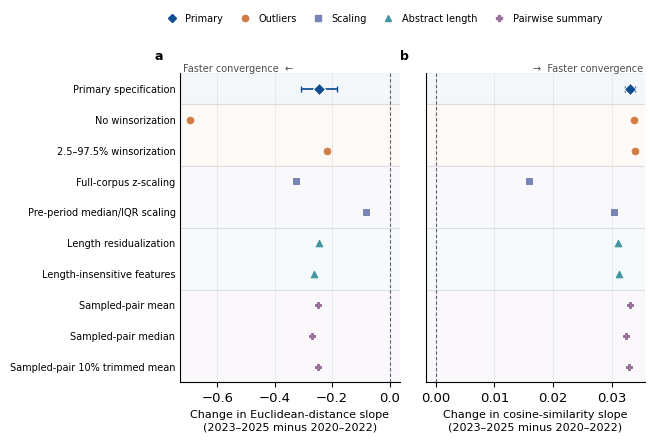

In [22]:
from matplotlib.lines import Line2D

specification_labels = {
    "primary_pre_z_winsor_1_99": "Primary specification",
    "no_winsorization": "No winsorization",
    "winsor_2_5_97_5": "2.5–97.5% winsorization",
    "full_corpus_z_scaling": "Full-corpus z-scaling",
    "pre_median_iqr_scaling": "Pre-period median/IQR scaling",
    "length_residualized": "Length residualization",
    "length_insensitive_features": "Length-insensitive features",
}
specification_order = list(specification_labels)
colors_robust = {
    "Primary": "#0F4D92", "Outliers": "#D17C45", "Scaling": "#7884B4",
    "Abstract length": "#42949E", "Pairwise summary": "#9A6F9A",
}
markers_robust = {
    "Primary": "D", "Outliers": "o", "Scaling": "s",
    "Abstract length": "^", "Pairwise summary": "P",
}
frame = robustness_slopes.set_index("specification").loc[specification_order].reset_index()
frame["label"] = frame["specification"].map(specification_labels)
sampled = pair_slopes.set_index("metric")
sampled_rows = []
for name, label, d_metric, c_metric in [
    ("sampled_pair_mean", "Sampled-pair mean", "mean_euclidean_distance", "mean_cosine_similarity"),
    ("sampled_pair_median", "Sampled-pair median", "median_euclidean_distance", "median_cosine_similarity"),
    ("sampled_pair_trimmed_mean", "Sampled-pair 10% trimmed mean", "trimmed_mean_euclidean_distance", "trimmed_mean_cosine_similarity"),
]:
    sampled_rows.append({
        "specification": name, "family": "Pairwise summary", "label": label,
        "distance_slope_change": sampled.loc[d_metric, "slope_change"],
        "cosine_slope_change": sampled.loc[c_metric, "slope_change"],
    })
robustness_plot = pd.concat([frame, pd.DataFrame(sampled_rows)], ignore_index=True)
bootstrap_lookup = cluster_bootstrap.set_index("estimand")

fig, axes = plt.subplots(1, 2, figsize=(183 / 25.4, 112 / 25.4), sharey=True, gridspec_kw={"wspace": 0.12})
for _, family_group in robustness_plot.groupby("family", sort=False):
    lo, hi = family_group.index.min() - 0.5, family_group.index.max() + 0.5
    for ax in axes:
        ax.axhspan(lo, hi, color=colors_robust[family_group.iloc[0]["family"]], alpha=0.045, zorder=0)
        if hi < len(robustness_plot) - 0.5:
            ax.axhline(hi, color="#D7DADF", linewidth=0.55)
for ax, column, bootstrap_key, xlabel, panel in [
    (axes[0], "distance_slope_change", "distance_slope_change", "Change in Euclidean-distance slope\n(2023–2025 minus 2020–2022)", "a"),
    (axes[1], "cosine_slope_change", "cosine_slope_change", "Change in cosine-similarity slope\n(2023–2025 minus 2020–2022)", "b"),
]:
    for index, row in robustness_plot.iterrows():
        family = row["family"]
        ax.scatter(row[column], index, s=38 if family == "Primary" else 23, marker=markers_robust[family], color=colors_robust[family], edgecolor="white" if family == "Primary" else colors_robust[family], linewidth=0.7, zorder=4)
    primary_value = robustness_plot.loc[robustness_plot["family"] == "Primary", column].iloc[0]
    boot = bootstrap_lookup.loc[bootstrap_key]
    ax.errorbar(primary_value, 0, xerr=np.array([[primary_value - boot["ci_low"]], [boot["ci_high"] - primary_value]]), fmt="none", ecolor=colors_robust["Primary"], elinewidth=1.25, capsize=2.5, capthick=1.0)
    ax.axvline(0, color="#5B6168", linewidth=0.8, linestyle=(0, (3, 2)))
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylim(len(robustness_plot) - 0.5, -0.5)
    ax.grid(axis="x", color="#E1E3E6", linewidth=0.5)
    ax.tick_params(axis="y", length=0)
    ax.text(-0.12, 1.035, panel, transform=ax.transAxes, fontsize=9, fontweight="bold", va="bottom")
axes[0].set_yticks(np.arange(len(robustness_plot)))
axes[0].set_yticklabels(robustness_plot["label"], fontsize=7)
axes[1].tick_params(labelleft=False)
axes[0].text(0.01, 1.005, "Faster convergence  ←", transform=axes[0].transAxes, fontsize=7, color="#4D4D4D")
axes[1].text(0.99, 1.005, "→  Faster convergence", transform=axes[1].transAxes, fontsize=7, color="#4D4D4D", ha="right")
handles = [Line2D([0], [0], marker=markers_robust[f], linestyle="none", color=colors_robust[f], markersize=4.5, label=f) for f in ["Primary", "Outliers", "Scaling", "Abstract length", "Pairwise summary"]]
fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.62, 1.015), ncol=5, fontsize=7, columnspacing=1.2, handletextpad=0.4)
fig.subplots_adjust(left=0.34, right=0.985, bottom=0.16, top=0.86)
plt.show()

## Feature-level dispersion and slope-change tests

In [23]:
CATEGORY_ORDER = [
    "Part of speech", "Lexical", "Syntactic", "Verb tenses",
    "Statistics", "Pronouns", "General",
]
CATEGORY_COLORS = {
    "Part of speech": "#4E79A7", "Lexical": "#59A14F",
    "Syntactic": "#F28E2B", "Verb tenses": "#B07AA1",
    "Statistics": "#E15759", "Pronouns": "#76B7B2",
    "General": "#9C755F",
}

def feature_category(code):
    if code.startswith("POS_"): return "Part of speech"
    if code.startswith("SY_"): return "Syntactic"
    if code.startswith("VT_"): return "Verb tenses"
    if code.startswith("ST_"): return "Statistics"
    if code.startswith("G_") or code == "VF_INFINITIVE": return "General"
    if code.startswith("L_") and "PRON" in code: return "Pronouns"
    return "Lexical"

def bh_fdr(p_values):
    p = np.asarray(p_values, dtype=float)
    order = np.argsort(p)
    ranked = p[order]
    adjusted = ranked * len(p) / np.arange(1, len(p) + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    output = np.empty_like(adjusted)
    output[order] = np.clip(adjusted, 0, 1)
    return output

contributions = []
variances = []
for year in YEARS:
    current = matrix_all[representation["Year"].to_numpy() == year]
    n = len(current)
    centered_sq = np.square(current - current.mean(axis=0, keepdims=True))
    mean_sq = centered_sq.mean(axis=0)
    correction = 2.0 * n / (n - 1)
    contributions.append(correction * mean_sq)
    influence = correction * (centered_sq - mean_sq)
    variances.append(influence.var(axis=0, ddof=1) / n)
codes = [c.removeprefix("z_") for c in feature_columns]
contribution = pd.DataFrame(np.vstack(contributions), index=YEARS, columns=codes)
variance = pd.DataFrame(np.vstack(variances), index=YEARS, columns=codes)
effective = contribution.loc[2020:2022].mean().loc[lambda x: x > 0].index.tolist()
contribution = contribution[effective]
variance = variance[effective]

pre_slope = (contribution.loc[2022] - contribution.loc[2020]) / 2
post_slope = (contribution.loc[2025] - contribution.loc[2023]) / 2
slope_change = post_slope - pre_slope
change_variance = (
    variance.loc[2025] + variance.loc[2023]
    + variance.loc[2022] + variance.loc[2020]
) / 4
standard_error = np.sqrt(change_variance)
z_score = slope_change / standard_error
p_value = 2 * norm.sf(np.abs(z_score))
q_value = bh_fdr(p_value)
feature_stats = pd.DataFrame({
    "feature": effective,
    "category": [feature_category(c) for c in effective],
    "pre_slope": pre_slope.to_numpy(),
    "post_slope": post_slope.to_numpy(),
    "slope_change": slope_change.to_numpy(),
    "standard_error": standard_error.to_numpy(),
    "ci_low": (slope_change - 1.96 * standard_error).to_numpy(),
    "ci_high": (slope_change + 1.96 * standard_error).to_numpy(),
    "p_value": p_value,
    "q_value": q_value,
})
feature_stats["fdr_significant"] = feature_stats["q_value"] < 0.05
feature_stats["direction"] = np.where(
    feature_stats["slope_change"] < 0,
    "faster convergence", "slower convergence",
)
feature_stats["category"] = pd.Categorical(
    feature_stats["category"], categories=CATEGORY_ORDER, ordered=True
)
feature_stats = feature_stats.sort_values(
    ["category", "slope_change", "feature"]
).reset_index(drop=True)
annual_feature = (
    contribution.rename_axis(index="Year", columns="feature")
    .stack().rename("dispersion_contribution").reset_index()
)
feature_stats.to_csv(SOURCE_DIR / "feature_slope_change_statistics.csv", index=False)
annual_feature.to_csv(SOURCE_DIR / "feature_annual_dispersion.csv", index=False)
print(f"Effective feature-level tests: {len(feature_stats)}")
print(f"FDR-significant features: {feature_stats['fdr_significant'].sum()}")
display(
    feature_stats.groupby(
        ["category", "direction"], observed=True
    )["fdr_significant"].sum().reset_index()
)

Effective feature-level tests: 94
FDR-significant features: 52


,category,direction,fdr_significant
0,Part of speech,faster convergence,1
1,Part of speech,slower convergence,1
2,Lexical,faster convergence,8
3,Lexical,slower convergence,5
4,Syntactic,faster convergence,1
5,Syntactic,slower convergence,1
6,Verb tenses,faster convergence,16
7,Verb tenses,slower convergence,1
8,Statistics,faster convergence,4
9,Statistics,slower convergence,3


## Feature-level forest plot

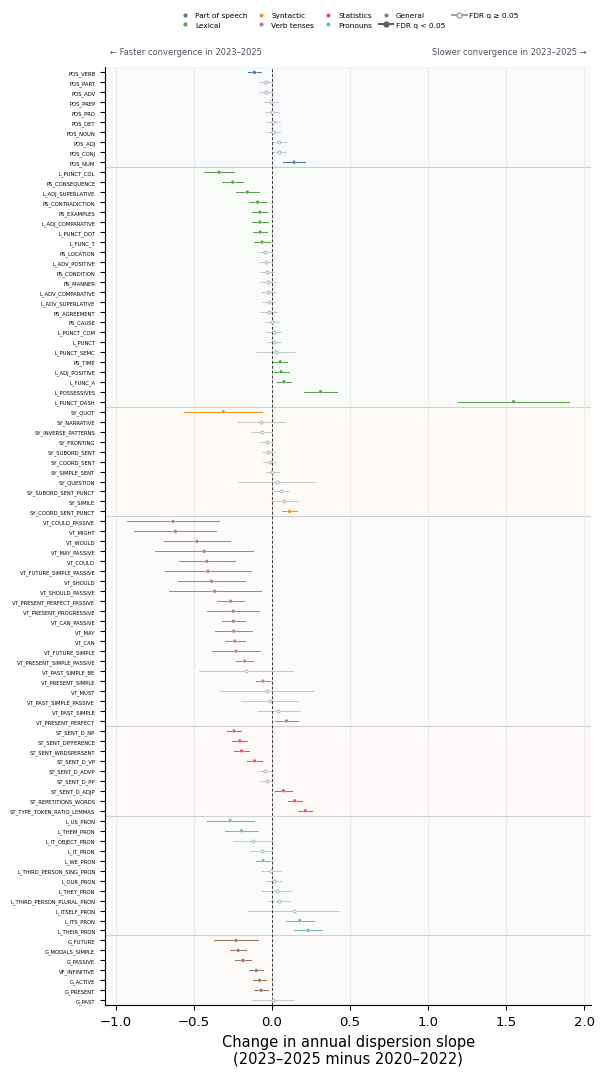

In [24]:
forest = pd.read_csv(SOURCE_DIR / "feature_slope_change_statistics.csv")
forest["category"] = pd.Categorical(forest["category"], CATEGORY_ORDER, ordered=True)
forest = forest.sort_values(["category", "slope_change", "feature"]).reset_index(drop=True)
y = np.arange(len(forest))
colors = np.array([CATEGORY_COLORS[str(c)] for c in forest["category"]])
significant_mask = forest["fdr_significant"].astype(bool).to_numpy()
fig, ax = plt.subplots(figsize=(183 / 25.4, 277 / 25.4))

starts = forest.groupby("category", observed=True, sort=False).head(1).index
ends = forest.groupby("category", observed=True, sort=False).tail(1).index
for start, end in zip(starts, ends):
    category = str(forest.loc[start, "category"])
    ax.axhspan(
        start - 0.5, end + 0.5,
        color=CATEGORY_COLORS[category], alpha=0.035, zorder=0,
    )
    if start > 0:
        ax.axhline(start - 0.5, color="#B8BEC6", linewidth=0.45, zorder=1)

for i, row in forest.iterrows():
    color = colors[i] if significant_mask[i] else "#A7ADB5"
    ax.plot(
        [row["ci_low"], row["ci_high"]], [i, i], color=color,
        linewidth=0.75 if significant_mask[i] else 0.45, zorder=2,
    )
ax.scatter(
    forest.loc[~significant_mask, "slope_change"], y[~significant_mask],
    s=5, facecolor="white", edgecolor="#8A919A", linewidth=0.45, zorder=3,
)
ax.scatter(
    forest.loc[significant_mask, "slope_change"], y[significant_mask],
    s=7, c=colors[significant_mask], edgecolor="white", linewidth=0.25, zorder=4,
)
ax.axvline(0, color="#31363B", linewidth=0.7, linestyle=(0, (3, 2)))
ax.set_yticks(y)
ax.set_yticklabels(forest["feature"], fontsize=3.8)
ax.set_ylim(len(forest) - 0.5, -0.5)
ax.set_xlabel("Change in annual dispersion slope\n(2023–2025 minus 2020–2022)")
ax.grid(axis="x", color="#D9DDE2", linewidth=0.4)
ax.text(
    0.01, 1.012, "← Faster convergence in 2023–2025",
    transform=ax.transAxes, ha="left", va="bottom", fontsize=6,
    color="#4B5563",
)
ax.text(
    0.99, 1.012, "Slower convergence in 2023–2025 →",
    transform=ax.transAxes, ha="right", va="bottom", fontsize=6,
    color="#4B5563",
)
handles = [
    plt.Line2D(
        [0], [0], marker="o", color="none",
        markerfacecolor=CATEGORY_COLORS[c], markeredgecolor="white",
        markersize=4, label=c,
    )
    for c in CATEGORY_ORDER
]
handles.extend([
    plt.Line2D([0], [0], marker="o", color="#5B6168", markerfacecolor="#5B6168", markersize=3.5, label="FDR q < 0.05"),
    plt.Line2D([0], [0], marker="o", color="#9AA1A9", markerfacecolor="white", markersize=3.5, label="FDR q ≥ 0.05"),
])
ax.legend(
    handles=handles, loc="lower center", bbox_to_anchor=(0.5, 1.035),
    ncol=5, fontsize=5.3, handletextpad=0.35, columnspacing=0.9,
)
fig.subplots_adjust(left=0.31, right=0.985, top=0.93, bottom=0.07)
plt.show()

## Annual trajectories of selected features and category means

In [25]:
significant = feature_stats.loc[feature_stats["fdr_significant"]].sort_values(
    ["category", "q_value", "slope_change"]
)
DISPLAY_NAMES = {
    "POS_NOUN": "Nouns", "POS_NUM": "Numerals", "POS_VERB": "Verbs",
    "POS_CONJ": "Conjunctions", "POS_ADJ": "Adjectives",
    "L_PUNCT_DASH": "Dashes", "L_PUNCT": "All punctuation",
    "L_PUNCT_COM": "Commas", "L_FUNC_A": "Function words",
    "L_PUNCT_DOT": "Full stops",
    "SY_COORD_SENT_PUNCT": "Coordinated clauses (punctuation)",
    "SY_SIMPLE_SENT": "Simple sentences",
    "SY_SUBORD_SENT_PUNCT": "Subordinate clauses (punctuation)",
    "SY_COORD_SENT": "Coordinated clauses",
    "SY_NARRATIVE": "Narrative structures",
    "VT_PRESENT_SIMPLE": "Present simple", "VT_CAN_PASSIVE": "Passive ‘can’",
    "VT_MIGHT": "‘Might’", "VT_CAN": "‘Can’", "VT_COULD": "‘Could’",
    "ST_TYPE_TOKEN_RATIO_LEMMAS": "Lemma type–token ratio",
    "ST_SENT_DIFFERENCE": "Adjacent-sentence count per word",
    "ST_SENT_WRDSPERSENT": "Sentence-length statistic",
    "ST_SENT_D_NP": "Noun-phrase dependency density",
    "ST_SENT_D_VP": "Verb-phrase dependency density",
    "L_US_PRON": "‘Us’", "L_OUR_PRON": "‘Our’", "L_THEM_PRON": "‘Them’",
    "G_ACTIVE": "Active voice", "G_PRESENT": "Present tense",
    "G_MODALS_SIMPLE": "Simple modal constructions",
    "G_PASSIVE": "Passive voice", "G_FUTURE": "Future tense",
}
selected = significant.groupby("category", observed=True, group_keys=False).head(5)
selected_annual = annual_feature.loc[
    annual_feature["feature"].isin(selected["feature"])
].merge(
    selected[["feature", "category", "slope_change", "q_value"]],
    on="feature", validate="many_to_one",
)
baseline = selected_annual.loc[selected_annual["Year"].between(2020, 2022)].groupby("feature")["dispersion_contribution"].mean()
selected_annual["pre_period_mean"] = selected_annual["feature"].map(baseline)
selected_annual["relative_dispersion"] = selected_annual["dispersion_contribution"] / selected_annual["pre_period_mean"]
selected_annual["display_name"] = selected_annual["feature"].map(DISPLAY_NAMES).fillna(selected_annual["feature"])

all_annual = annual_feature.merge(
    feature_stats[["feature", "category"]], on="feature", validate="many_to_one"
)
all_baseline = all_annual.loc[all_annual["Year"].between(2020, 2022)].groupby("feature")["dispersion_contribution"].mean()
all_annual["pre_period_mean"] = all_annual["feature"].map(all_baseline)
all_annual = all_annual.loc[all_annual["pre_period_mean"] > 0].copy()
all_annual["relative_dispersion"] = all_annual["dispersion_contribution"] / all_annual["pre_period_mean"]
category_average = all_annual.groupby(["category", "Year"], observed=True).agg(
    mean_relative_dispersion=("relative_dispersion", "mean"),
    median_relative_dispersion=("relative_dispersion", "median"),
    n_features=("feature", "nunique"),
).reset_index()

selected.to_csv(SOURCE_DIR / "category_feature_selection.csv", index=False)
selected_annual.to_csv(SOURCE_DIR / "selected_feature_annual_trajectories.csv", index=False)
category_average.to_csv(SOURCE_DIR / "category_average_trajectories.csv", index=False)
display(selected[["category", "feature", "slope_change", "q_value"]])
display(category_average)

,category,feature,slope_change,q_value
0,Part of speech,POS_VERB,-0.112614,2.544035e-06
9,Part of speech,POS_NUM,0.141100,2.658131e-04
33,Lexical,L_PUNCT_DASH,1.548212,4.210389e-16
11,Lexical,PS_CONSEQUENCE,-0.251772,1.548337e-12
10,Lexical,L_PUNCT_COL,-0.339242,1.349731e-10
32,Lexical,L_POSSESSIVES,0.311908,4.240552e-08
12,Lexical,L_ADJ_SUPERLATIVE,-0.157961,1.373838e-04
44,Syntactic,SY_COORD_SENT_PUNCT,0.112887,1.338009e-05
34,Syntactic,SY_QUOT,-0.312289,2.655845e-02
57,Verb tenses,VT_CAN,-0.238179,1.736685e-11


,category,Year,mean_relative_dispersion,median_relative_dispersion,n_features
0,Part of speech,2020,1.029601,1.033433,10
1,Part of speech,2021,0.987668,0.988588,10
2,Part of speech,2022,0.982731,0.980386,10
3,Part of speech,2023,0.970605,0.970656,10
4,Part of speech,2024,0.939261,0.933060,10
5,Part of speech,2025,0.929095,0.909111,10
6,Lexical,2020,1.017331,1.031737,24
7,Lexical,2021,0.982291,0.987799,24
8,Lexical,2022,1.000379,0.981918,24
9,Lexical,2023,0.973086,0.950710,24


## Feature and category trajectory panels

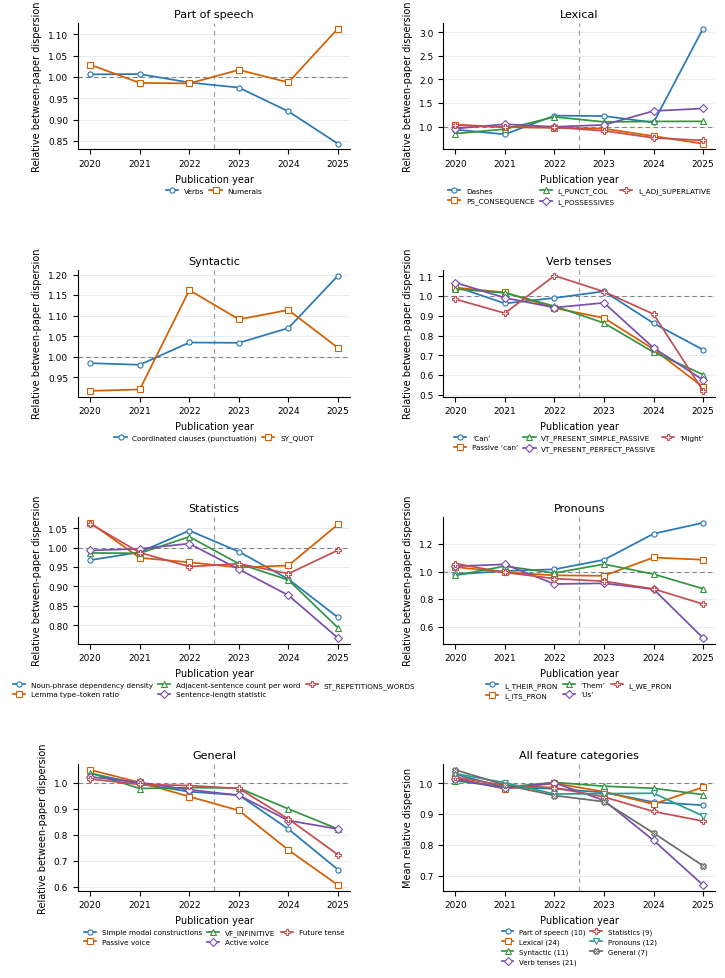

In [27]:
selected_plot = pd.read_csv(SOURCE_DIR / "selected_feature_annual_trajectories.csv")
average_plot = pd.read_csv(SOURCE_DIR / "category_average_trajectories.csv")
colors = ["#2878B5", "#D55E00", "#35943F", "#7A4EAB", "#C44E52"]
markers = ["o", "s", "^", "D", "P"]
average_colors = {
    "Part of speech": "#2878B5", "Lexical": "#D55E00",
    "Syntactic": "#35943F", "Verb tenses": "#7A4EAB",
    "Statistics": "#C44E52", "Pronouns": "#2A9D8F", "General": "#6B6B6B",
}
average_markers = {
    "Part of speech": "o", "Lexical": "s", "Syntactic": "^",
    "Verb tenses": "D", "Statistics": "P", "Pronouns": "v", "General": "X",
}
fig, axes = plt.subplots(4, 2, figsize=(183 / 25.4, 245 / 25.4))
for ax, category in zip(axes.flat[:7], CATEGORY_ORDER):
    part = selected_plot.loc[selected_plot["category"] == category].copy()
    ordered_features = (
        part[["feature", "q_value"]].drop_duplicates().sort_values("q_value")["feature"].tolist()
    )
    for i, feature in enumerate(ordered_features):
        group = part.loc[part["feature"] == feature]
        group = group.sort_values("Year")
        label = str(group["display_name"].iloc[0])
        ax.plot(
            group["Year"], group["relative_dispersion"],
            marker=markers[i % len(markers)], color=colors[i % len(colors)],
            markerfacecolor="white", markeredgewidth=0.8,
            markersize=3.7, linewidth=1.25, label=label, zorder=3,
        )
    ax.axvline(2022.5, color="#9CA3AF", linestyle=(0, (4, 3)), lw=0.9)
    ax.axhline(1, color="#7B848D", linestyle=(0, (4, 3)), lw=0.8)
    ax.set_title(category, fontsize=8.0, pad=4)
    ax.set_xticks(YEARS)
    ax.tick_params(labelsize=6.5)
    ax.set_xlabel("Publication year", fontsize=7)
    ax.set_ylabel("Relative between-paper dispersion", fontsize=7)
    ax.grid(axis="y", color="#D5D9DE", linewidth=0.45, alpha=0.85)
    ncol = 2 if len(ordered_features) <= 4 else 3
    ax.legend(
        loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=ncol,
        fontsize=5.2, handlelength=1.7, columnspacing=0.7,
    )

ax = axes.flat[7]
for category in CATEGORY_ORDER:
    group = average_plot.loc[average_plot["category"] == category].sort_values("Year")
    ax.plot(
        group["Year"], group["mean_relative_dispersion"],
        marker=average_markers[category], markerfacecolor="white",
        markeredgewidth=0.8, markersize=3.7, linewidth=1.25,
        color=average_colors[category],
        label=f"{category} ({int(group['n_features'].iloc[0])})", zorder=3,
    )
ax.axvline(2022.5, color="#9CA3AF", linestyle=(0, (4, 3)), lw=0.9)
ax.axhline(1, color="#7B848D", linestyle=(0, (4, 3)), lw=0.8)
ax.set_title("All feature categories", fontsize=8.0, pad=4)
ax.set_xticks(YEARS)
ax.tick_params(labelsize=6.5)
ax.set_xlabel("Publication year", fontsize=7)
ax.set_ylabel("Mean relative dispersion", fontsize=7)
ax.grid(axis="y", color="#D5D9DE", linewidth=0.45, alpha=0.85)
ax.legend(
    loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=2,
    fontsize=5.0, handlelength=1.7, columnspacing=0.7,
)

fig.subplots_adjust(left=0.10, right=0.985, top=0.97, bottom=0.07, hspace=0.95, wspace=0.34)
plt.show()